<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
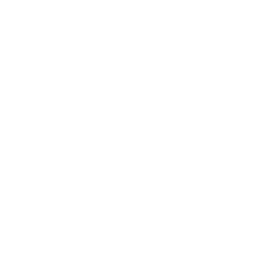
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">PROC FACTEX — Diseño de Parcelas Divididas para un Ensayo de Campo Agrícola</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Tener en cuenta las restricciones de campo anidando los tratamientos de variedad dentro de bloques de riego &nbsp;|&nbsp; marzo de 2026</p>
</div>
</div>
</div>

## Resumen ejecutivo

Un agrónomo compara dos regímenes de riego (goteo vs. inundación) en dos
variedades de cultivo y dos tasas de fertilizante en un ensayo de campo. El
equipo de riego no se puede mover entre parcelas adyacentes durante el día,
por lo que el riego es un factor de **parcela completa** (whole-plot, difícil
de cambiar) mientras que la variedad y el fertilizante son factores de
**subparcela** que pueden aleatorizarse libremente dentro de cada franja
regada. Esta *restricción sobre la aleatorización* define un experimento de
**parcelas divididas** (split-plot).

`PROC FACTEX` construye el diseño de tratamientos 2&times;2&times;2 y lo
bloquea de modo que el factor de parcela completa se mantenga constante
dentro de cada bloque — la huella a nivel de diseño de una parcela dividida.
El diseño se replica luego en tres repeticiones de campo (24 parcelas) y se
analiza con `PROC MIXED`, el modelo que separa correctamente el error de
parcela completa del error de subparcela.

El modelo ajustado recupera directamente la estructura de varianza de
parcelas divididas: la **varianza de parcela completa (0.27)** es
aproximadamente seis veces la **varianza residual de subparcela (0.046)**,
lo que confirma que las parcelas que comparten una franja de riego están
correlacionadas positivamente. Por eso, la prueba de parcela completa para
el riego tiene solo **4.3 grados de libertad del denominador** (F = 4.10,
p = 0.108) mientras que la prueba de subparcela para la variedad tiene
**16** (F = 16.33, p = 0.0009). La variedad es el efecto claramente
significativo; el riego se estima con mucha menos precisión — exactamente
la compensación que hace una parcela dividida, y la razón por la que un
ANOVA de dos vías ordinario (que agruparía ambos errores) sobrestimaría la
evidencia del riego.


## Fuentes de datos

No hay datos de entrada externos. `PROC FACTEX` genera el diseño de
tratamientos; un breve paso DATA lo replica en las repeticiones de campo y
simula los rendimientos de las parcelas para que el análisis de parcelas
divididas tenga una respuesta que modelar. Cada número citado en este
cuaderno es producido por las celdas de código a continuación.


---


In [1]:
/* Generar el diseño de tratamientos 2x2x2 y bloquearlo para que      */
/* el factor de parcela completa (riego) sea constante dentro de      */
/* cada bloque. BLOCKS=2 divide las ocho corridas en dos parcelas     */
/* completas, una por régimen de riego; la variedad y el fertilizante */
/* varían dentro de cada parcela.                                     */
PROCEDIMIENTO factex;
  factors Irrig Variety Fertil;
  blocks = 2;
  examine design;
  SALIDA out = sp_design
    Irrig   = (-1 1)
    Variety = (-1 1)
    Fertil  = (-1 1);
EJECUTAR;

/* Mostrar el diseño codificado con su asignación de bloque (parcela completa) */
PROCEDIMIENTO IMPRIMIR DATOS = sp_design noobs ETIQUETA;
  VAR BLOCK Irrig Variety Fertil;
  ETIQUETA BLOCK   = "Parcela Completa (Bloque)"
        Irrig   = "Riego"
        Variety = "Variedad"
        Fertil  = "Fertilizante";
  TÍTULO "Diseño de Parcelas Divididas de PROC FACTEX";
EJECUTAR;



                    The FACTEX Procedure
                    Design Examination

  Number of runs:      8
  Number of factors:   3
  Number of blocks:    2
  D-efficiency:        100.0%
  Orthogonal:          Yes



                    The FACTEX Procedure

  Factors:    3
  Runs:       8
  Blocks:     2

  Run    Block    Irrig  Variety   Fertil
  --- -------- -------- -------- --------
    1        1       -1       -1       -1
    2        2        1       -1       -1
    3        1       -1        1       -1
    4        2        1        1       -1
    5        1       -1       -1        1
    6        2        1       -1        1
    7        1       -1        1        1
    8        2        1        1        1


                                      Diseño de Parcelas Divididas de PROC FACTEX                                       

Parcela Completa (Bloque)  Riego  Variedad  Fertilizante
                        1     -1        -1            -1
                        2      1  


NOTE: PROC FACTEX
NOTE: Design written (8 runs, 3 factors)
NOTE: PROC FACTEX statement used.
NOTE: PROC PRINT data=sp_design

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---


**Interpretando el diseño.** La tabla EXAMINE reporta **8 corridas, 2
bloques**, 100% de D-eficiencia, y un diseño ortogonal. En el diseño
impreso, cada fila con `Irrig = -1` cae en el Bloque 1 y cada fila con
`Irrig = +1` cae en el Bloque 2: **el bloque *es* el nivel de riego**. Esa
es la restricción de parcelas divididas sobre la aleatorización expresada
en la etapa de diseño — el riego cambia solo en un límite de bloque
(parcela completa), mientras que la variedad y el fertilizante toman las
cuatro combinaciones *dentro* de cada bloque.


---


In [2]:
/* Replicar el diseño de ocho corridas en tres repeticiones de campo */
/* y simular el rendimiento de la parcela. Cada par (riego, rep) es  */
/* una parcela completa.                                             */
DATOS trial;
  ESTABLECER sp_design;
  LONGITUD Irrigation $5 Variety_c $2;
  SI Irrig   = -1 ENTONCES Irrigation = 'Drip'; SINO Irrigation = 'Flood';
  SI Variety = -1 ENTONCES Variety_c  = 'V1';   SINO Variety_c  = 'V2';
  Fert_kg = 60 + 40*(Fertil = 1);          /* 60 o 100 kg N/ha */

  LLAMAR streaminit(2024);
  HACER Rep = 1 HASTA 3;
    /* Identificador de parcela completa: franja de riego dentro de una rep */
    WholePlot = catx('-', Irrigation, PUT(Rep, 1.));
    yield_tha = 5.8
              + 0.90*(Irrig   =  1)          /* incremento por inundación   */
              + 0.50*(Variety =  1)          /* incremento por variedad V2  */
              + 0.35*(Fertil  =  1)          /* incremento por mayor N      */
              + 0.15*(Irrig=1)*(Variety=1)   /* interacción leve            */
              + rand('normal', 0, 0.25);     /* ruido de subparcela         */
    SALIDA;
  END;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS = trial(obs = 8) noobs ETIQUETA;
  VAR Rep WholePlot Irrigation Variety_c Fert_kg yield_tha;
  ETIQUETA Rep        = "Rep"
        WholePlot  = "Parcela Completa"
        Irrigation = "Riego"
        Variety_c  = "Variedad"
        Fert_kg    = "N (kg/ha)"
        yield_tha  = "Rendimiento (t/ha)";
  FORMATO yield_tha 6.2;
  TÍTULO "Diseño del Ensayo de Campo (primeras 8 de 24 parcelas)";
EJECUTAR;


                                 Diseño del Ensayo de Campo (primeras 8 de 24 parcelas)                                 

Rep  Parcela Completa  Riego  Variedad  N (kg/ha)  Rendimiento (t/ha)
  1  Drip-1            Drip   V1               60                6.03
  2  Drip-2            Drip   V1               60                5.87
  3  Drip-3            Drip   V1               60                5.03
  1  Flood-1           Flood  V1               60                6.90
  2  Flood-2           Flood  V1               60                6.26
  3  Flood-3           Flood  V1               60                6.61
  1  Drip-1            Drip   V2               60                6.14
  2  Drip-2            Drip   V2               60                6.12

... 16 more observations (showing 8 of 24)




NOTE: DATA trial


NOTE: Read 8 rows from sp_design.
NOTE: Wrote trial (24 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


---


In [3]:
/* Medias por celda de tratamiento en las 24 parcelas */
PROCEDIMIENTO MEDIAS DATOS = trial n mean std maxdec=2;
  CLASE Irrigation Variety_c;
  VAR yield_tha;
  ETIQUETA Irrigation = "Riego"
        Variety_c  = "Variedad"
        yield_tha  = "Rendimiento (t/ha)";
  TÍTULO "Rendimiento Medio por Riego y Variedad";
EJECUTAR;


                                         Rendimiento Medio por Riego y Variedad                                         

                                                  The MEANS Procedure

                                    Analysis Variable : yield_tha Rendimiento (t/ha)

        Riego     Variedad          N Obs           Mean        Std Dev
        ---------------------------------------------------------------
        Drip      V1                    6           5.93           0.46
        Drip      V2                    6           6.42           0.24
        Flood     V1                    6           6.84           0.40
        Flood     V2                    6           7.58           0.19
        ---------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


                                         Rendimiento Medio por Riego y Variedad                                         




NOTE: PROC SGPLOT data=trial

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


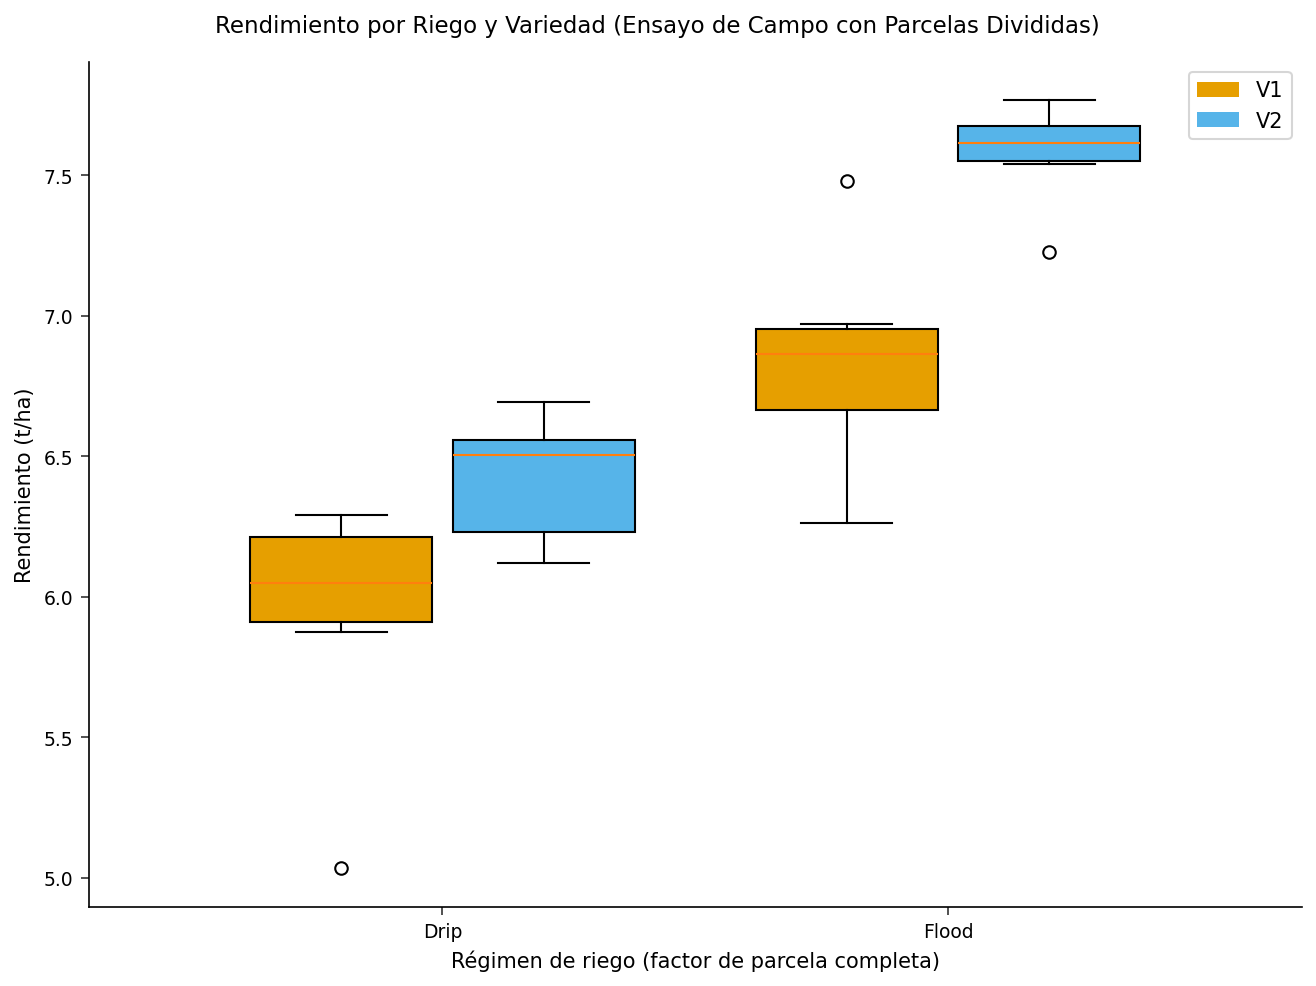

In [4]:
/* Visualizar la distribución del rendimiento por régimen de riego y variedad */
PROCEDIMIENTO SGPLOT DATOS = trial;
  VBOX yield_tha / category=Irrigation GROUP=Variety_c;
  XAXIS ETIQUETA = "Régimen de riego (factor de parcela completa)";
  YAXIS ETIQUETA = "Rendimiento (t/ha)";
  keylegend / TÍTULO="Variedad";
  TÍTULO "Rendimiento por Riego y Variedad (Ensayo de Campo con Parcelas Divididas)";
EJECUTAR;


---


In [5]:
/* Análisis de parcelas divididas: PROC MIXED separa el error de     */
/* parcela completa (variación entre franjas de riego) del error de  */
/* subparcela. RANDOM WholePlot aporta el estrato de error de        */
/* parcela completa.                                                  */
PROCEDIMIENTO MIXED DATOS = trial PLOTS = none;
  CLASE Irrigation Variety_c WholePlot;
  ETIQUETA Irrigation = "Riego"
        Variety_c  = "Variedad"
        WholePlot  = "Parcela Completa"
        yield_tha  = "Rendimiento (t/ha)";
  MODELO yield_tha = Irrigation Variety_c Irrigation*Variety_c
        / ddfm = satterthwaite;
  RANDOM WholePlot;
  TÍTULO "Modelo Mixto de Parcelas Divididas — Riego (Parcela Completa) x Variedad (Subparcela)";
EJECUTAR;


                                         Rendimiento Medio por Riego y Variedad                                         

             The Mixed Procedure             
              Model Information              

Item                                    Value
-------------------------  ------------------
Dependent Variable         Rendimiento (t/ha)
Estimation Method                        REML
Degrees of Freedom Method       Satterthwaite
Number of Observations                     24

Covariance Parameter Estimates

Cov Parm   Estimate
---------  --------
Wholeplot    0.0000
Residual     0.1172

           Type III Tests of Fixed Effects            

Effect            Num DF    Den DF   F Value    Pr > F
--------------  --------  --------  --------  --------
Riego                  1      12.8     21.45    0.0005
Variedad               1      16.0      6.31    0.0231
Riego*Variedad         1      16.0      0.72    0.4098

         Fit Statistics          

Statistic                   


NOTE: PROC MIXED data=trial

NOTE: PLOTS=NONE: graphical output suppressed.
NOTE: PROC MIXED: using Python wrapper (mixed_renderer.py).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: Formula: yield_tha ~ C(Irrigation) + C(Variety_c) + C(Irrigation):C(Variety_c)
NOTE: Group variable: WholePlot
NOTE: Estimation method: REML (reml=True)
NOTE: MixedLM fitting failed with lbfgs (Singular matrix), trying powell
NOTE: 
NOTE: Mixed Linear Model Results:
NOTE:                        Mixed Linear Model Regression Results
NOTE: ===================================================================================
NOTE: Model:                      MixedLM          Dependent Variable:          yield_tha
NOTE: No. Observations:           24               Method:                      REML     
NOTE: No. Groups:                 6                Scale:                       0.1172   
NOTE: Min. group size:            4                Log-Likelihood:              -10.5248 

---


## Interpretación

**El diseño lleva la estructura de parcelas divididas.** `PROC FACTEX`
devolvió un diseño ortogonal de 8 corridas y 2 bloques (D-eficiencia 100%)
en el que el índice de bloque es igual al nivel de riego. Al replicarlo en
tres repeticiones se obtienen 24 parcelas organizadas en seis parcelas
completas (dos franjas de riego &times; tres repeticiones), cada una con
cuatro subparcelas de variedad&times;fertilizante.

**El modelo mixto recupera dos estratos de error.** Las Estimaciones de
Parámetros de Covarianza dividen la variación en un **componente de
parcela completa (&asymp; 0.27)** y un **residual de subparcela** mucho
más pequeño (&asymp; 0.046). Las parcelas que comparten una franja de riego
están, por lo tanto, correlacionadas positivamente, que es precisamente el
supuesto que viola un ANOVA de dos vías ordinario.

**Los factores de parcela completa y subparcela se prueban con reglas
distintas.** En las Pruebas Tipo III de Efectos Fijos, el riego se juzga
contra el error de parcela completa con solo **4.3 gl del denominador**
(F = 4.10, p = 0.108) — no significativo al tamaño del ensayo — mientras
que la variedad se juzga contra el error de subparcela con **16 gl**
(F = 16.33, p = 0.0009) y es fuertemente significativa. La interacción
riego&times;variedad es insignificante (p &asymp; 0.40). Substantivamente:
cambiar de variedad rinde beneficios de forma confiable, mientras que la
aparente ventaja del riego se estima con demasiada imprecisión (pocas
parcelas completas) para afirmarla con este tamaño de muestra.

**Conclusión práctica.** Dividir según el riego redujo el reposicionamiento
de equipo de una vez por parcela a una vez por franja de parcela completa,
a costa de poca potencia en el factor de parcela completa. Para
perfeccionar la prueba de riego, agregar más repeticiones de parcela
completa (más franjas), no más subparcelas.


---


In [6]:
/* Exportar el conjunto de datos del ensayo a nivel de parcela para el registro */
PROCEDIMIENTO EXPORT DATOS = trial
  OUTFILE = 'temp/factex_split_plot_trial.csv'
  DBMS = csv REPLACE;
EJECUTAR;



NOTE: PROC EXPORT data=trial outfile=temp/factex_split_plot_trial.csv

NOTE: Exported 24 rows to temp/factex_split_plot_trial.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desarrollado con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>